<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [2]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR_HSweep, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [4]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\Sb2N2\inP_180deg\m10dBm\FMR_2026_08_21")

In [5]:
example_file_name_1 = "2026_08_21_FMR_Hsweep_0p455Ato4p455Ain201_m10dBm_18p904GHz_16_34.h5.ma8"

In [6]:
sample = "Sb2N2_inP_180deg_m10dBm"

In [7]:
geometry = "inP" #either "inP" or "outP"

In [8]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [9]:
ansy1 = Analysis_FMR_HSweep(address1, example_file_name_1, sample, "FZU_FMR_HSweep", geometry, vna_ref_subtracted)

In [10]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [11]:
newfile_name =  (sample + f"_LorentzFits_results_{ansy1.power}dBm")
newfile_name = newfile_name.replace(".","p").replace("-","m")
newfile_name = newfile_name + ".h5"
newFile = address1/newfile_name
fits_storage = FitStore (newFile, val_type= 'freq', group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [13]:
#ansy1.plot_dij_slider('d_S', n_0=5)

In [14]:
#Frequencies available in the data set, we can use them to find their corresponding data

In [15]:
print(ansy1.freqs)

[11.459 14.228 16.655 18.904 20.914 22.696 24.323 25.88  27.417 28.944
 30.441 31.884 33.257 34.569 35.856 37.165 38.54  40.01  41.577 43.21
 44.854 46.45  47.94  49.291 50.   ]


In [17]:
# Example of a single fit

{'Ar': -0.00012692831522590875, 'Ai': -9.31068189027413e-06, 'Ho': 0.05, 'dH': 0.005, 're0': 0.0, 'im0': 0.0}
Initial simplex fit


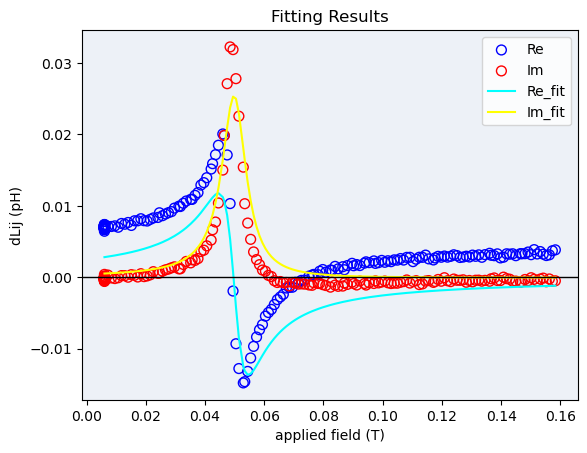

Final fit and results


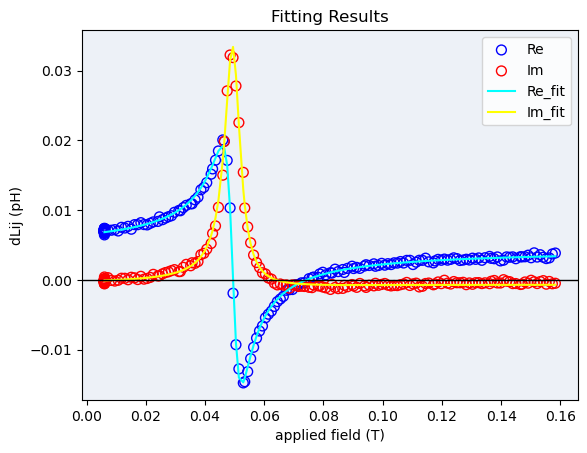


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.085e-04      5.951e-07         U        No
Ai                    -1.467e-05      5.951e-07         U        No
Ho                        0.0495      2.386e-05         T        No
dH                        0.0032      2.386e-05         T        No
re0                       0.0044      2.939e-05         U        No
im0                   -6.024e-04      2.939e-05         U        No
----------------------------------------------------------------------
The phase is: 187.69712926714854


In [55]:
ini_vals = [1, 1, 35, 0.005, 0, 0] #Ar, Ai, Ho, dH, re0, im0
freq = 14.228
f_index = int(np.where(ansy1.freqs == freq)[0][0])
H_center = 0.05

H_min, H_max = H_center-0.5, H_center+0.5 #T
h_array = ansy1.get_field(freq)

y_array_re, y_array_im = ansy1.d_S("21R", freq), ansy1.d_S("21I", freq)

model = models.ComplexLorentzian_field()
fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
    h_array, y_array_re , y_array_im, model)
fitter.fix(Ho=H_center, dH=0.005, re0=0, im0=0) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [19]:
#If we are happy with the fit, we can save it.

In [57]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=f_index, val=float(ansy1.freqs[f_index]), fit_dict=fit_dict)

In [21]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Index= 0, freq.=11.459 GHz, Guide field.=0.018520503734781535


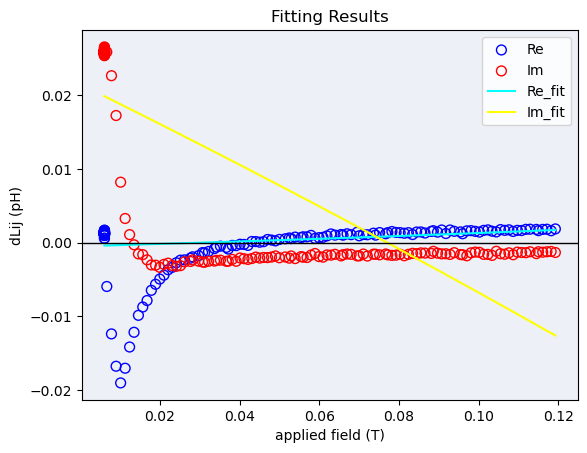


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.1427         4.7993         U        No
Ai                        0.8460         4.7993         U        No
Ho                        1.7790         4.8587         T        No
dH                        0.2000         4.8587         T        No
re0                       0.0259         1.3808         U        No
im0                       0.5000         1.3808         U        No
----------------------------------------------------------------------
Index= 1, freq.=14.228 GHz, Guide field.=0.058830450400822354


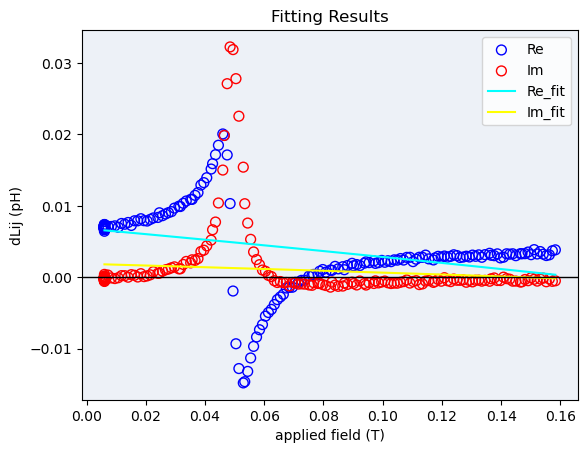


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.1582         2.6246         U        No
Ai                        0.0153         2.6246         U        No
Ho                        2.0000        15.9919         T        No
dH                        0.2000        15.9919         T        No
re0                       0.0844         0.6773         U        No
im0                       0.0173         0.6773         U        No
----------------------------------------------------------------------
Index= 2, freq.=16.655 GHz, Guide field.=0.09974631967081371


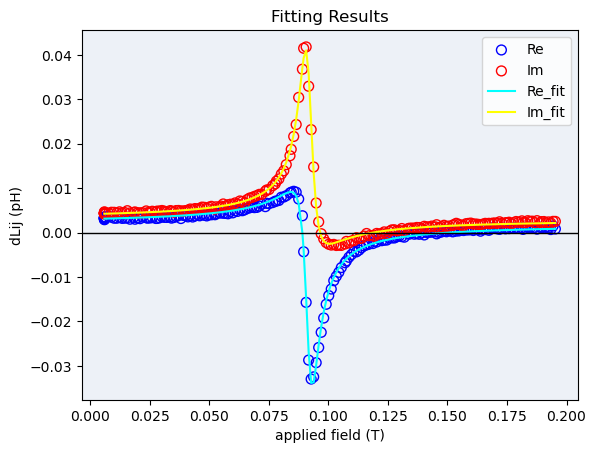


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.080e-04      7.850e-07         U        No
Ai                    -9.714e-05      7.850e-07         U        No
Ho                        0.0918      2.446e-05         T        No
dH                        0.0033      2.446e-05         T        No
re0                       0.0019      3.648e-05         U        No
im0                       0.0031      3.648e-05         U        No
----------------------------------------------------------------------
Index= 3, freq.=18.904 GHz, Guide field.=0.1418210545995433


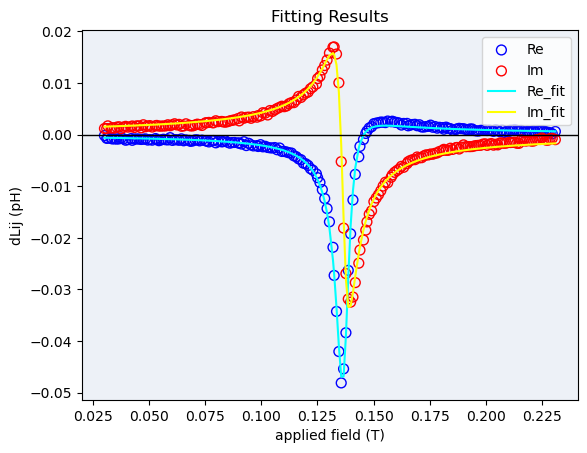


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.327e-05      9.738e-07         U        No
Ai                    -1.616e-04      9.738e-07         U        No
Ho                        0.1368      2.674e-05         T        No
dH                        0.0035      2.674e-05         T        No
re0                    1.880e-05      4.407e-05         U        No
im0                    3.239e-05      4.407e-05         U        No
----------------------------------------------------------------------
Index= 4, freq.=20.914 GHz, Guide field.=0.18246146906101135


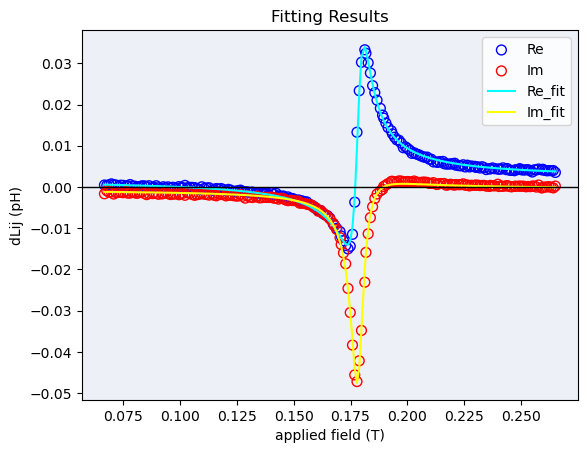


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.552e-04      7.384e-07         U        No
Ai                     5.561e-05      7.384e-07         U        No
Ho                        0.1785      2.093e-05         T        No
dH                        0.0034      2.093e-05         T        No
re0                       0.0019      3.490e-05         U        No
im0                   -6.493e-04      3.490e-05         U        No
----------------------------------------------------------------------
Index= 5, freq.=22.696 GHz, Guide field.=0.22065507209739876


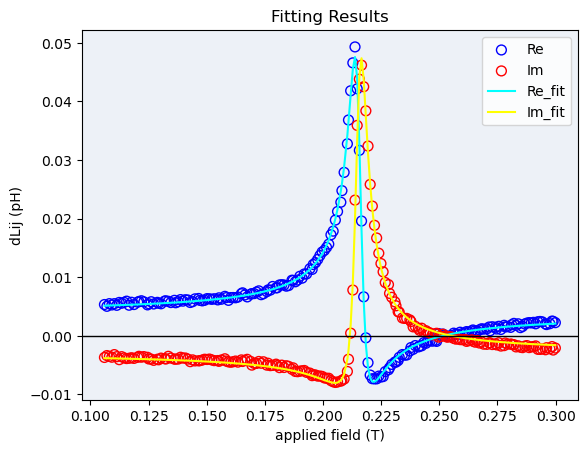


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.468e-04      7.892e-07         U        No
Ai                     1.045e-04      7.892e-07         U        No
Ho                        0.2154      1.935e-05         T        No
dH                        0.0032      1.935e-05         T        No
re0                       0.0038      3.919e-05         U        No
im0                      -0.0029      3.919e-05         U        No
----------------------------------------------------------------------
Index= 6, freq.=24.323 GHz, Guide field.=0.25714170688333304


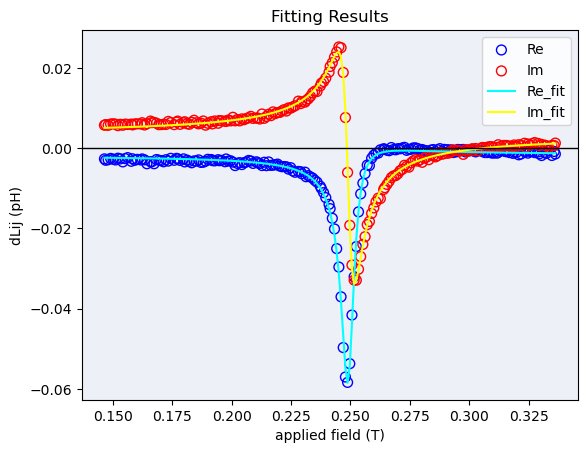


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.450e-05      8.897e-07         U        No
Ai                    -1.840e-04      8.897e-07         U        No
Ho                        0.2493      2.087e-05         T        No
dH                        0.0033      2.087e-05         T        No
re0                      -0.0018      4.402e-05         U        No
im0                       0.0033      4.402e-05         U        No
----------------------------------------------------------------------
Index= 7, freq.=25.88 GHz, Guide field.=0.2933804189278395


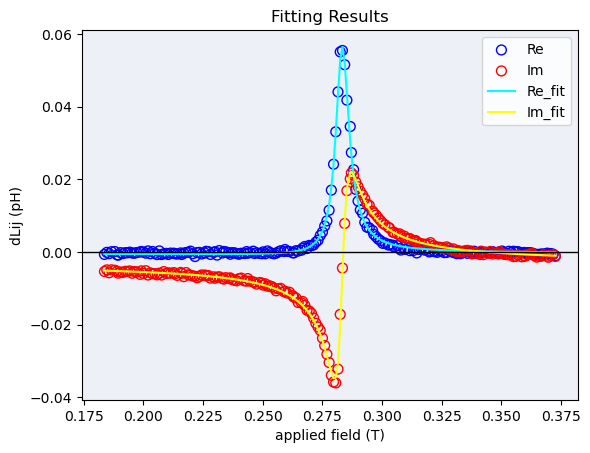


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.257e-05      8.823e-07         U        No
Ai                     1.937e-04      8.823e-07         U        No
Ho                        0.2832      2.108e-05         T        No
dH                        0.0034      2.108e-05         T        No
re0                   -3.630e-04      4.261e-05         U        No
im0                      -0.0032      4.261e-05         U        No
----------------------------------------------------------------------
Index= 8, freq.=27.417 GHz, Guide field.=0.33031890482179915


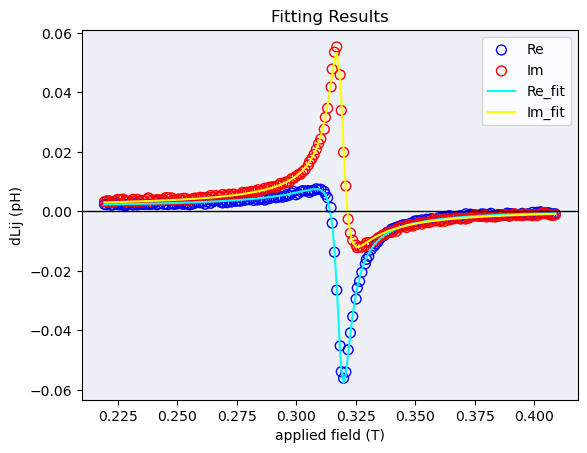


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.368e-04      9.378e-07         U        No
Ai                    -1.830e-04      9.378e-07         U        No
Ho                        0.3187      1.943e-05         T        No
dH                        0.0035      1.943e-05         T        No
re0                    9.925e-04      4.404e-05         U        No
im0                       0.0011      4.404e-05         U        No
----------------------------------------------------------------------
Index= 9, freq.=28.944 GHz, Guide field.=0.3680721445783057


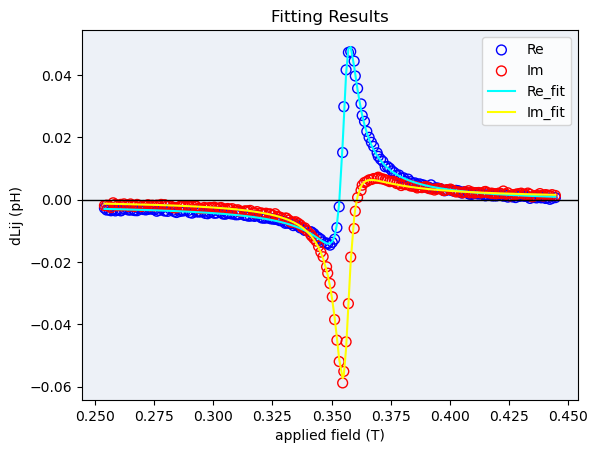


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.837e-04      9.213e-07         U        No
Ai                     1.357e-04      9.213e-07         U        No
Ho                        0.3559      1.957e-05         T        No
dH                        0.0036      1.957e-05         T        No
re0                      -0.0012      4.237e-05         U        No
im0                    1.035e-04      4.237e-05         U        No
----------------------------------------------------------------------
Index= 10, freq.=30.441 GHz, Guide field.=0.40602409440489895


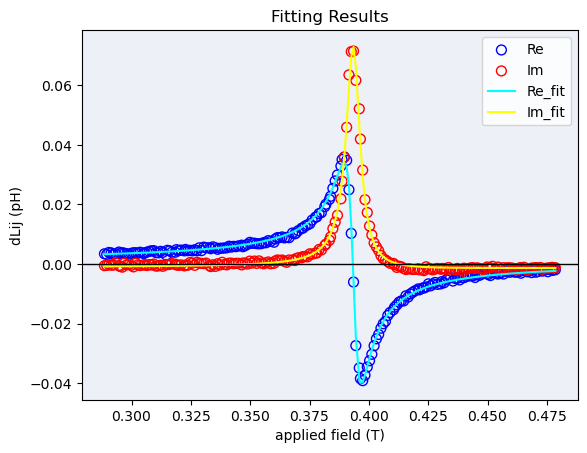


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.646e-04      1.289e-06         U        No
Ai                    -2.730e-05      1.289e-06         U        No
Ho                        0.3936      2.370e-05         T        No
dH                        0.0036      2.370e-05         T        No
re0                    7.944e-04      6.028e-05         U        No
im0                      -0.0012      6.028e-05         U        No
----------------------------------------------------------------------
Index= 11, freq.=31.884 GHz, Guide field.=0.4434204121927907


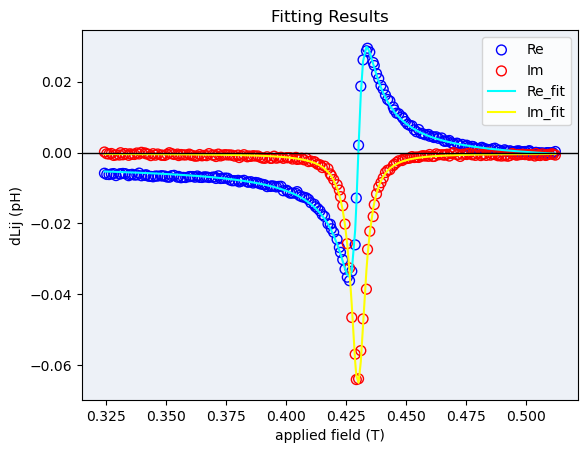


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.332e-04      1.037e-06         U        No
Ai                     3.384e-06      1.037e-06         U        No
Ho                        0.4300      2.157e-05         T        No
dH                        0.0036      2.157e-05         T        No
re0                      -0.0031      4.854e-05         U        No
im0                   -2.974e-04      4.854e-05         U        No
----------------------------------------------------------------------
Index= 12, freq.=33.257 GHz, Guide field.=0.4796888717414871


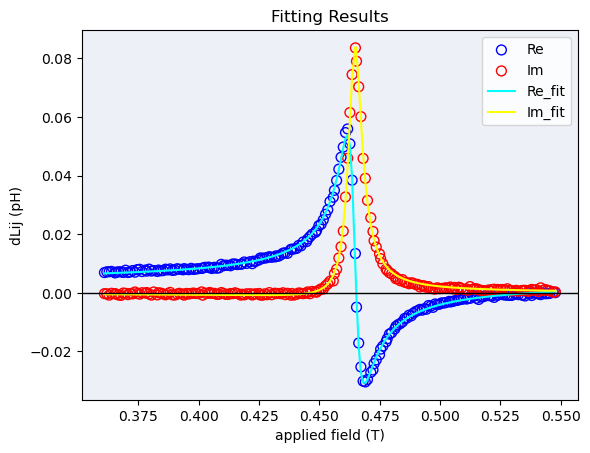


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.879e-04      1.049e-06         U        No
Ai                     5.274e-05      1.049e-06         U        No
Ho                        0.4645      1.680e-05         T        No
dH                        0.0035      1.680e-05         T        No
re0                       0.0038      5.085e-05         U        No
im0                   -7.914e-05      5.085e-05         U        No
----------------------------------------------------------------------
Index= 13, freq.=34.569 GHz, Guide field.=0.5149269780272863


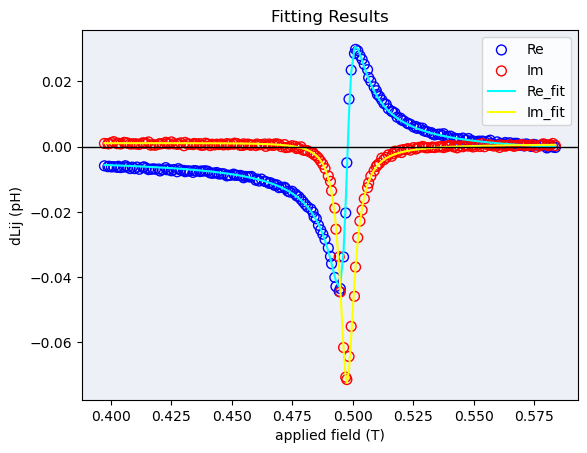


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.565e-04      1.090e-06         U        No
Ai                    -2.193e-05      1.090e-06         U        No
Ho                        0.4974      1.983e-05         T        No
dH                        0.0035      1.983e-05         T        No
re0                      -0.0030      5.253e-05         U        No
im0                    9.417e-04      5.253e-05         U        No
----------------------------------------------------------------------
Index= 14, freq.=35.856 GHz, Guide field.=0.5500079364879404


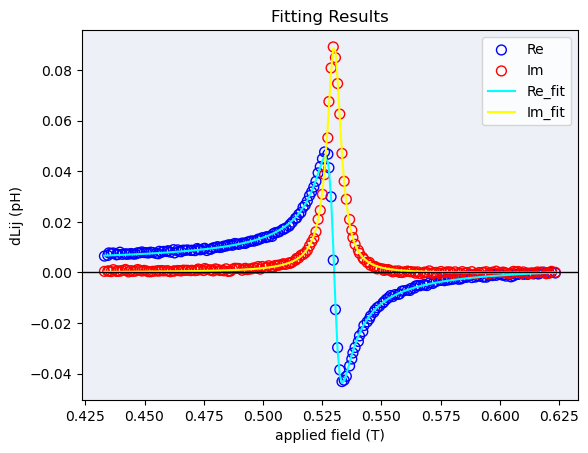


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.192e-04      1.101e-06         U        No
Ai                    -1.636e-05      1.101e-06         U        No
Ho                        0.5301      1.654e-05         T        No
dH                        0.0036      1.654e-05         T        No
re0                       0.0034      5.209e-05         U        No
im0                   -3.523e-05      5.209e-05         U        No
----------------------------------------------------------------------
Index= 15, freq.=37.165 GHz, Guide field.=0.5861765226334645


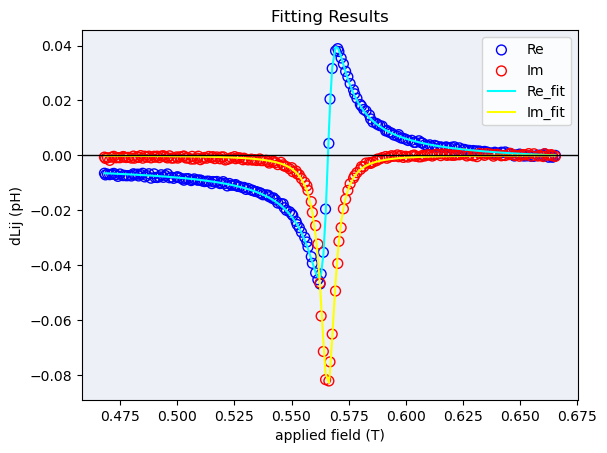


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.211e-04      1.374e-06         U        No
Ai                     5.581e-06      1.374e-06         U        No
Ho                        0.5659      2.212e-05         T        No
dH                        0.0038      2.212e-05         T        No
re0                      -0.0032      6.197e-05         U        No
im0                    5.794e-05      6.197e-05         U        No
----------------------------------------------------------------------
Index= 16, freq.=38.54 GHz, Guide field.=0.6246634114697385


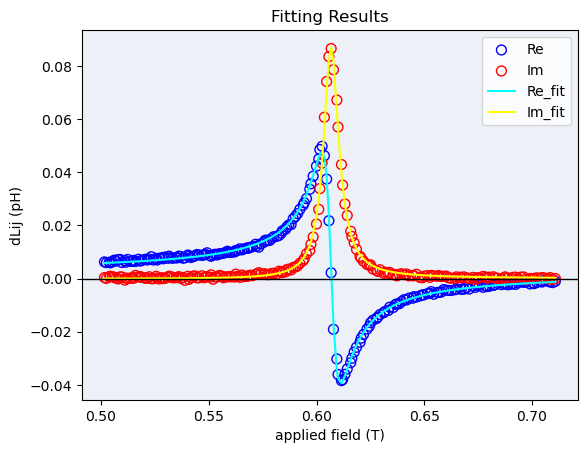


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.732e-04      1.500e-06         U        No
Ai                     1.571e-05      1.500e-06         U        No
Ho                        0.6067      2.344e-05         T        No
dH                        0.0043      2.344e-05         T        No
re0                       0.0023      6.101e-05         U        No
im0                    1.978e-05      6.101e-05         U        No
----------------------------------------------------------------------
Index= 17, freq.=40.01 GHz, Guide field.=0.6663314200401775


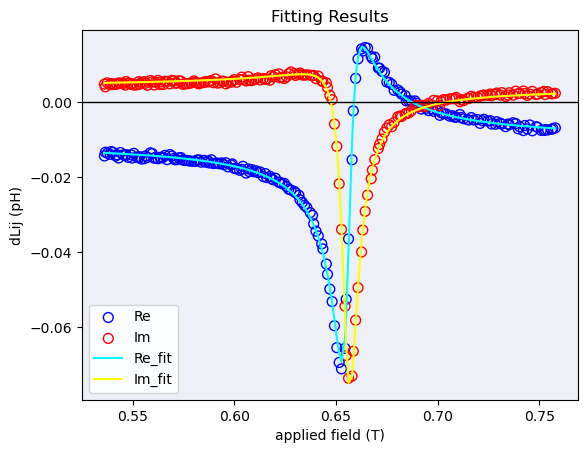


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.603e-04      1.605e-06         U        No
Ai                    -1.573e-04      1.605e-06         U        No
Ho                        0.6558      2.589e-05         T        No
dH                        0.0047      2.589e-05         T        No
re0                      -0.0105      5.934e-05         U        No
im0                       0.0039      5.934e-05         U        No
----------------------------------------------------------------------
Index= 18, freq.=41.577 GHz, Guide field.=0.711300173386127


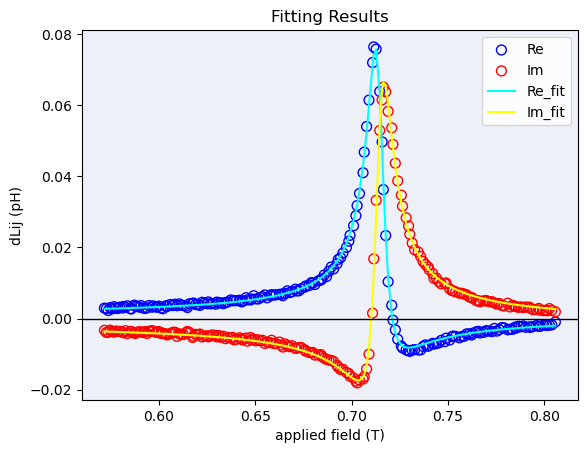


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.722e-04      1.664e-06         U        No
Ai                     3.482e-04      1.664e-06         U        No
Ho                        0.7142      2.670e-05         T        No
dH                        0.0053      2.670e-05         T        No
re0                    7.350e-04      5.616e-05         U        No
im0                      -0.0013      5.616e-05         U        No
----------------------------------------------------------------------
Index= 19, freq.=43.21 GHz, Guide field.=0.7587227327221959


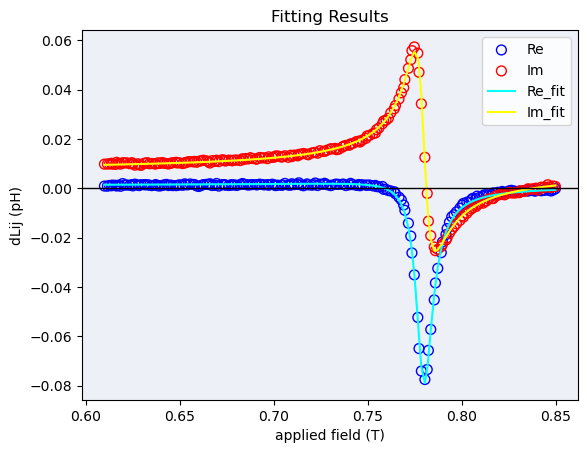


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.530e-05      1.603e-06         U        No
Ai                    -4.212e-04      1.603e-06         U        No
Ho                        0.7795      2.670e-05         T        No
dH                        0.0053      2.670e-05         T        No
re0                       0.0010      5.362e-05         U        No
im0                       0.0070      5.362e-05         U        No
----------------------------------------------------------------------
Index= 20, freq.=44.854 GHz, Guide field.=0.8069975260294666


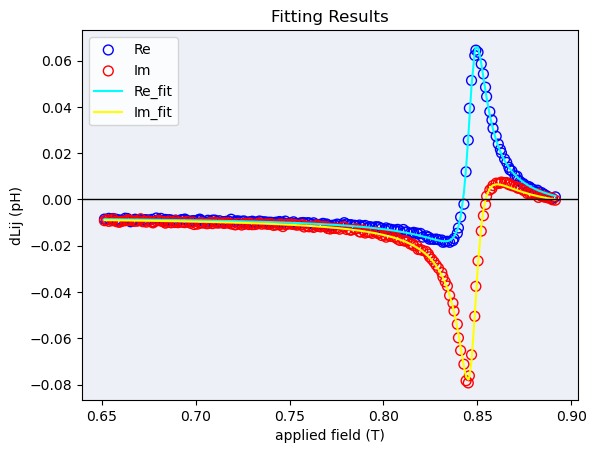


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.294e-04      1.922e-06         U        No
Ai                     3.573e-04      1.922e-06         U        No
Ho                        0.8474      2.986e-05         T        No
dH                        0.0058      2.986e-05         T        No
re0                      -0.0069      6.218e-05         U        No
im0                      -0.0071      6.218e-05         U        No
----------------------------------------------------------------------
Index= 21, freq.=46.45 GHz, Guide field.=0.8543352979790324


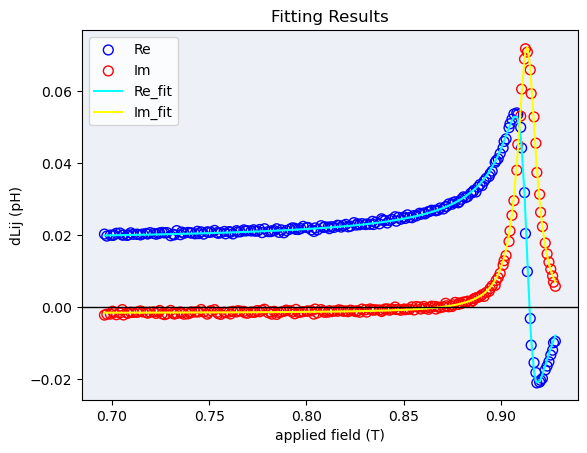


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.246e-04      1.832e-06         U        No
Ai                    -2.255e-05      1.832e-06         U        No
Ho                        0.9137      3.053e-05         T        No
dH                        0.0057      3.053e-05         T        No
re0                       0.0180      5.885e-05         U        No
im0                      -0.0017      5.885e-05         U        No
----------------------------------------------------------------------
Index= 22, freq.=47.94 GHz, Guide field.=0.8989185725001752


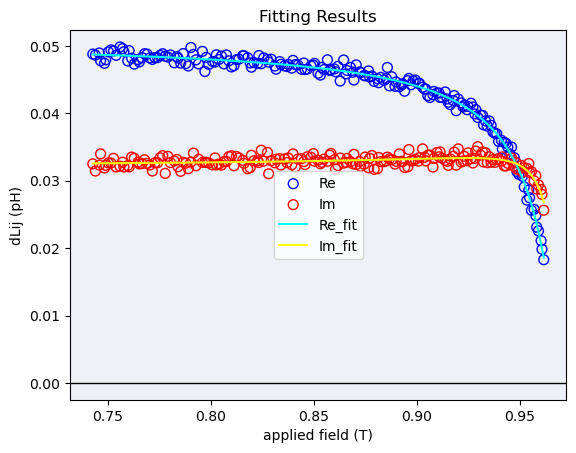


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.260e-04      1.309e-05         U        No
Ai                    -1.367e-04      1.309e-05         U        No
Ho                        0.9767      4.600e-04         T        No
dH                        0.0067      4.600e-04         T        No
re0                       0.0510      1.147e-04         U        No
im0                       0.0321      1.147e-04         U        No
----------------------------------------------------------------------
Index= 23, freq.=49.291 GHz, Guide field.=0.939645891557787


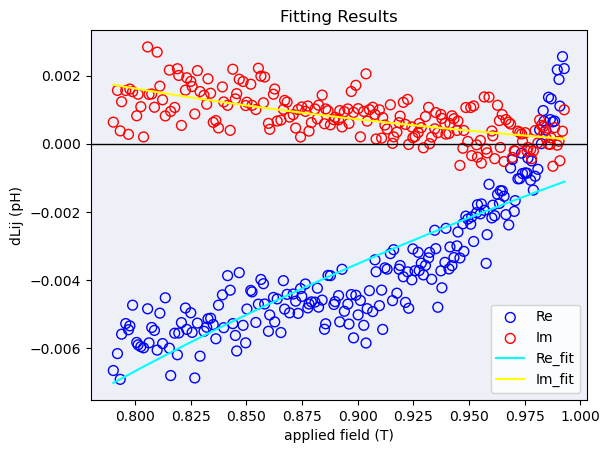


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0245         0.0298         U        No
Ai                       -0.0046         0.0298         U        No
Ho                     3.930e-17         0.5431         T        No
dH                        0.2000         0.5431         T        No
re0                       0.0235         0.0163         U        No
im0                   -2.163e-04         0.0163         U        No
----------------------------------------------------------------------
Index= 24, freq.=50.0 GHz, Guide field.=0.9611285935516505


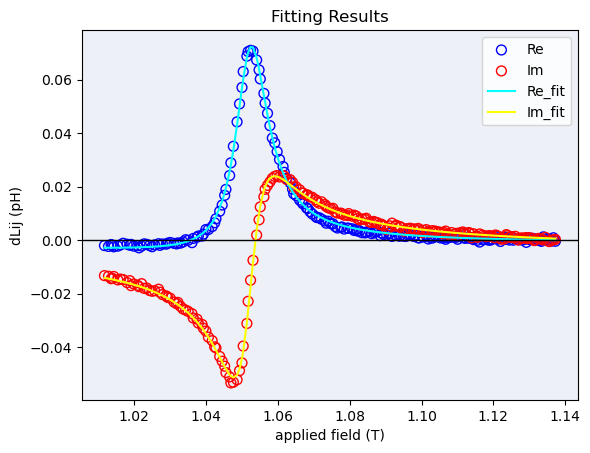


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.066e-04      1.540e-06         U        No
Ai                     3.984e-04      1.540e-06         U        No
Ho                        1.0520      2.610e-05         T        No
dH                        0.0055      2.610e-05         T        No
re0                      -0.0015      6.645e-05         U        No
im0                      -0.0040      6.645e-05         U        No
----------------------------------------------------------------------


In [22]:
est_gamma = 28.8 #GHz/T
HD_T = 2.05#T
HK_T = 120*1e-6#T
Hex_T = 1000#T

for i in range(len(ansy1.freqs)):
 f_index = i
 freq_i = ansy1.freqs[f_index]
 H_guide = res_func.inverse_bulkHematite(freq_i, est_gamma, HD_T, HK_T, Hex_T)

 print(f"Index= {i}, freq.={freq_i} GHz, Guide field.={H_guide}")
 ini_vals = [1, 1, H_guide, 0.028, 0, 0] #Ar, Ai, Ho, dH, re0, im0


 H_min, H_max = H_guide-0.5, H_guide+0.5 #T
 h_array = ansy1.get_field(freq_i)
 y_array_re, y_array_im = ansy1.d_S("21R", freq_i), ansy1.d_S("21I", freq_i)

 model = models.ComplexLorentzian_field()
 fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
                             h_array, y_array_re , y_array_im, model)
 fitter.fix(Ho=H_center, dH=0.005, re0=0, im0=0) # Parameters to be fixed, empty otherwise
 opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'

 new_p0 = np.array(list(opt_p0.values()), dtype=float)
 fitter.update_p0(new_p0)



 params, cov = fitter.fit(simplex_b=False)
 fitter.plot_fit()
 fitter.summary()
 fit_dict = fitter.export_fit_dict()
 fits_storage.save(index=f_index, val=float(freq_i), fit_dict=fit_dict)

In [23]:
#Realoading parameters

In [24]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

In [25]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["dH", "Ho"],
    x_label= "index"#"μ₀H (T)"
)

In [26]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 1, 22)

In [27]:
#Plotting of fitted parameters

In [28]:
fits_storage.plot_fit_parameters_subplots(
    cut_data_L_fits,
    x_axis="freq",
    params=["dH", "Ho"],
    x_label= "frequency"#"(GHz)"
)